# Fine-tune Qwen3-4B-Instruct-2507 (QLoRA) trên qa_dataset.json

Notebook chạy trên **Colab Free (T4 16GB)**. Vì Qwen3-4B (~4B params) lớn hơn ngưỡng LoRA fp16 trên T4, bắt buộc dùng **QLoRA 4-bit (NF4)**.

Các bước:
1. Chuẩn bị & kiểm tra dữ liệu (split train/val/test, dedup, JSONL chuẩn `messages`).
2. Load model base 4-bit + tokenizer.
3. Cấu hình LoRA + SFTTrainer.
4. Train + lưu adapter.
5. Đánh giá BLEU / ROUGE-L / BERTScore trước & sau fine-tune.

## 0. Cài thư viện (chạy lần đầu)

In [1]:
# !pip -q install -U "transformers>=4.53.0" "peft>=0.14.0" "trl>=0.14.0" "accelerate>=1.3.0" \
#     "bitsandbytes>=0.44.1" "datasets>=3.1.0" sentencepiece
# !pip -q install -U evaluate sacrebleu rouge-score bert-score pyvi

## 1. Chuẩn bị & kiểm tra dữ liệu

In [2]:
import json, random, re, hashlib, os
from collections import Counter
from pathlib import Path

# random.seed(42)

# DATA_PATH = 'qa_dataset.json'   # đổi nếu để Drive: '/content/drive/MyDrive/.../qa_dataset.json'
OUT_DIR = Path('data')
OUT_DIR.mkdir(exist_ok=True)

# with open(DATA_PATH, 'r', encoding='utf-8') as f:
#     data = json.load(f)

# print(f'Tổng số mẫu: {len(data)}')
# print('Phân bố type   :', Counter(d.get('type') for d in data))
# print('Phân bố subtype:', Counter(d.get('subtype') for d in data))
# print('Phân bố split  :', Counter(d.get('split') for d in data))

In [3]:
# # 1a. Khử trùng lặp gần đúng theo (jd_id, normalized user question)
# def get_user_q(sample):
#     for m in sample['messages']:
#         if m['role'] == 'user':
#             return m['content']
#     return ''

# def norm(s):
#     s = s.lower()
#     s = re.sub(r'\s+', ' ', s).strip()
#     return s

# seen, dedup = set(), []
# for d in data:
#     jd_id = (d.get('_meta') or {}).get('jd_id', '')
#     key = hashlib.md5((str(jd_id) + '||' + norm(get_user_q(d))).encode()).hexdigest()
#     if key in seen:
#         continue
#     seen.add(key)
#     dedup.append(d)
# print(f'Sau dedup: {len(dedup)} (giảm {len(data)-len(dedup)})')

In [4]:
# # 1b. Tách train / val / test (theo split sẵn có; nếu thiếu test ≥ 50 thì rút từ train)
# by_split = {'train': [], 'val': [], 'test': []}
# for d in dedup:
#     s = d.get('split') or 'train'
#     if s not in by_split:
#         s = 'train'
#     by_split[s].append(d)

# # Đảm bảo test ≥ 50: nếu thiếu, rút ngẫu nhiên từ train, tránh trùng jd_id với train còn lại
# MIN_TEST = 50
# if len(by_split['test']) < MIN_TEST:
#     need = MIN_TEST - len(by_split['test'])
#     random.shuffle(by_split['train'])
#     moved = by_split['train'][:need]
#     by_split['train'] = by_split['train'][need:]
#     by_split['test'].extend(moved)

# # Nếu chưa có val, tách ~10% từ train
# if len(by_split['val']) == 0:
#     random.shuffle(by_split['train'])
#     n_val = max(20, len(by_split['train']) // 10)
#     by_split['val'] = by_split['train'][:n_val]
#     by_split['train'] = by_split['train'][n_val:]

# # Anti-leak: bỏ mọi mẫu train trùng jd_id với test
# test_jd = {(d.get('_meta') or {}).get('jd_id') for d in by_split['test']}
# by_split['train'] = [d for d in by_split['train'] if (d.get('_meta') or {}).get('jd_id') not in test_jd]
# by_split['val']   = [d for d in by_split['val']   if (d.get('_meta') or {}).get('jd_id') not in test_jd]

# print({k: len(v) for k, v in by_split.items()})
# assert len(by_split['train']) >= 300, 'Train < 300, cần thêm dữ liệu!'
# assert len(by_split['test'])  >= 50,  'Test < 50, cần thêm dữ liệu!'

In [5]:
# # 1c. Ghi JSONL chuẩn — mỗi dòng = {"messages": [...]} cho SFTTrainer chat-format
# def write_jsonl(path, samples):
#     with open(path, 'w', encoding='utf-8') as f:
#         for d in samples:
#             f.write(json.dumps({'messages': d['messages']}, ensure_ascii=False) + '\n')

# write_jsonl(OUT_DIR / 'train.jsonl', by_split['train'])
# write_jsonl(OUT_DIR / 'val.jsonl',   by_split['val'])
# write_jsonl(OUT_DIR / 'test.jsonl',  by_split['test'])
# print('Đã ghi data/{train,val,test}.jsonl')

## 2. Load tokenizer + model base (QLoRA 4-bit)

In [6]:
import os
from pathlib import Path

# Use a writable cache directory to avoid read-only filesystem errors.
HF_CACHE_DIR = Path("hf_cache")
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE_DIR)
os.environ["TRANSFORMERS_CACHE"] = str(HF_CACHE_DIR)
os.environ["HF_DATASETS_CACHE"] = str(HF_CACHE_DIR)

print("HF cache dir:", HF_CACHE_DIR.resolve())

HF cache dir: /media/urlab/KINGSTON/nlp/hf_cache


In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = 'Qwen/Qwen3-4B-Instruct-2507'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, trust_remote_code=True, cache_dir=str(HF_CACHE_DIR)
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    cache_dir=str(HF_CACHE_DIR),
)
model.config.use_cache = False
model.config.pretraining_tp = 1
print('OK — model loaded in 4-bit')

/home/urlab/miniconda3/envs/uav_ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 558.97it/s]


OK — model loaded in 4-bit


## 3 + 4. Cấu hình LoRA & train với SFTTrainer

In [8]:
from peft import LoraConfig, prepare_model_for_kbit_training
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
import inspect

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
)

ds_train = load_dataset('json', data_files=str(OUT_DIR/'train.jsonl'), split='train')
ds_val   = load_dataset('json', data_files=str(OUT_DIR/'val.jsonl'),   split='train')

OUTPUT_DIR = 'qwen3-4b-qlora-jd'

sft_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=12,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=1e-4,
    lr_scheduler_type='cosine',
    warmup_ratio=0.03,
    optim='paged_adamw_8bit',
    bf16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    logging_steps=10,
    eval_strategy='steps',
    eval_steps=50,
    save_strategy='steps',
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to='none',
    max_seq_length=1536,
    packing=False,
    dataset_kwargs={'skip_prepare_dataset': False},
)

# Handle TRL API differences across versions.
sft_sig = inspect.signature(SFTConfig.__init__)
if 'eval_strategy' not in sft_sig.parameters and 'evaluation_strategy' in sft_sig.parameters:
    sft_kwargs['evaluation_strategy'] = sft_kwargs.pop('eval_strategy')
sft_kwargs = {k: v for k, v in sft_kwargs.items() if k in sft_sig.parameters}
sft_config = SFTConfig(**sft_kwargs)

trainer_kwargs = dict(
    model=model,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    peft_config=lora_config,
    args=sft_config,
)
trainer_sig = inspect.signature(SFTTrainer.__init__)
if 'processing_class' in trainer_sig.parameters:
    trainer_kwargs['processing_class'] = tokenizer
else:
    trainer_kwargs['tokenizer'] = tokenizer

trainer = SFTTrainer(**trainer_kwargs)

Generating train split: 762 examples [00:00, 207954.95 examples/s]
Generating train split: 94 examples [00:00, 91710.76 examples/s]
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Tokenizing eval dataset: 100%|██████████| 94/94 [00:00<00:00, 1332.64 examples/s]


In [9]:
trainer.train()
trainer.save_model(OUTPUT_DIR + '/best')
tokenizer.save_pretrained(OUTPUT_DIR + '/best')
print('Adapter saved →', OUTPUT_DIR + '/best')

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
50,0.991880,0.910270
100,0.720629,0.713835
150,0.513446,0.585676
200,0.354185,0.495055
250,0.251598,0.439070
300,0.168545,0.402939
350,0.130432,0.384555
400,0.108127,0.374101
450,0.100986,0.376499
500,0.093437,0.376248


Adapter saved → qwen3-4b-qlora-jd/best


Using: qwen3-4b-qlora-jd/checkpoint-576/trainer_state.json


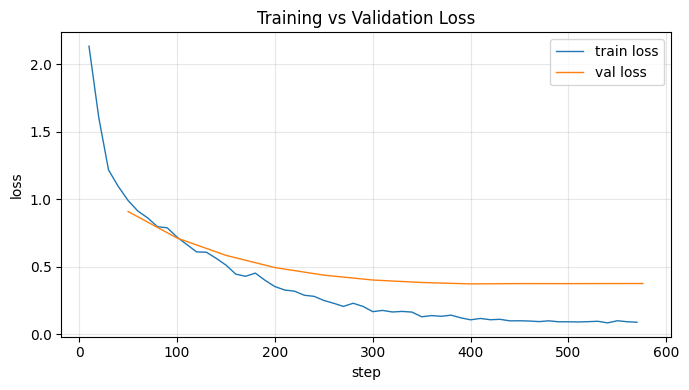

In [15]:
# 4b. Plot training and validation loss on one chart
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

out_dir = Path(OUTPUT_DIR)
state_files = sorted(
    out_dir.glob("checkpoint-*/trainer_state.json"),
    key=lambda p: int(p.parent.name.split("-")[-1]),
)
if not state_files:
    raise FileNotFoundError(f"No trainer_state.json found under {out_dir}")

state_path = state_files[-1]
print("Using:", state_path)

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

log_history = state.get("log_history", [])
if not log_history:
    raise ValueError("log_history is empty in trainer_state.json")

df_hist = pd.DataFrame(log_history)

x_col = "step" if "step" in df_hist.columns else ("epoch" if "epoch" in df_hist.columns else None)
if x_col is None:
    raise ValueError("No 'step' or 'epoch' column in log_history")

train_df = df_hist[df_hist["loss"].notna()][[x_col, "loss"]] if "loss" in df_hist.columns else pd.DataFrame()
val_df = df_hist[df_hist["eval_loss"].notna()][[x_col, "eval_loss"]] if "eval_loss" in df_hist.columns else pd.DataFrame()

if train_df.empty and val_df.empty:
    raise ValueError("No loss metrics found in log_history")

plt.figure(figsize=(7, 4))
if not train_df.empty:
    plt.plot(train_df[x_col], train_df["loss"], label="train loss", linewidth=1)
if not val_df.empty:
    plt.plot(val_df[x_col], val_df["eval_loss"], label="val loss", linewidth=1)

plt.xlabel(x_col)
plt.ylabel("loss")
plt.title("Training vs Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 5. Đánh giá trước & sau fine-tune

Chạy inference trên `test.jsonl` cho 2 model: **base** và **fine-tuned** (base + adapter), cùng decoding params (greedy, max_new_tokens=256). Sau đó tính BLEU / ROUGE-L / BERTScore.

In [10]:
# 5a. Hàm inference dùng chung
import json, gc, torch
from tqdm import tqdm

def load_test(path):
    items = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line)
            msgs = obj['messages']
            ref = next((m['content'] for m in msgs if m['role']=='assistant'), '')
            prompt_msgs = [m for m in msgs if m['role'] != 'assistant']
            items.append({'prompt_msgs': prompt_msgs, 'reference': ref})
    return items

test_items = load_test(OUT_DIR/'test.jsonl')
print('Test size:', len(test_items))

@torch.inference_mode()
def generate_all(model, tokenizer, items, out_path, max_new_tokens=256):
    model.eval()
    preds = []
    with open(out_path, 'w', encoding='utf-8') as f:
        for it in tqdm(items):
            inputs = tokenizer.apply_chat_template(
                it['prompt_msgs'], add_generation_prompt=True,
                tokenize=True, return_dict=True, return_tensors='pt'
            ).to(model.device)
            out = model.generate(
                **inputs, max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
            )
            text = tokenizer.decode(out[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True).strip()
            preds.append(text)
            f.write(json.dumps({'pred': text, 'reference': it['reference']}, ensure_ascii=False) + '\n')
    return preds

def free():
    gc.collect(); torch.cuda.empty_cache()

Test size: 100


In [11]:
# 5b. Inference với BASE model (model hiện trong RAM đang là base + adapter sau train).
# Cách an toàn: unload, reload base sạch để chấm baseline, sau đó load lại adapter cho FT.
del trainer, model
free()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map='auto',
    trust_remote_code=True, torch_dtype=torch.bfloat16,
    cache_dir=str(HF_CACHE_DIR),
)
base_model.config.use_cache = True
generate_all(base_model, tokenizer, test_items, 'pred_base.jsonl')
del base_model; free()

100%|██████████| 100/100 [06:14<00:00,  3.75s/it]


In [12]:
# 5c. Inference với FINE-TUNED (base + LoRA adapter)
from peft import PeftModel

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map='auto',
    trust_remote_code=True, torch_dtype=torch.bfloat16,
    cache_dir=str(HF_CACHE_DIR),
)
ft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR + '/best')
ft_model.config.use_cache = True
generate_all(ft_model, tokenizer, test_items, 'pred_ft.jsonl')
del ft_model, base_model; free()

100%|██████████| 100/100 [04:53<00:00,  2.94s/it]


In [16]:
# 5d. Tính BLEU, ROUGE-L, BERTScore, EM, METEOR
import json
import re
import sacrebleu
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from pyvi import ViTokenizer

try:
    import nltk
    from nltk.translate.meteor_score import meteor_score as nltk_meteor
    _meteor_ok = True
except Exception as e:
    nltk_meteor = None
    _meteor_ok = False
    print("Warning: METEOR unavailable:", e)


def load_pred(path):
    preds, refs = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            o = json.loads(line)
            preds.append(o['pred']); refs.append(o['reference'])
    return preds, refs


def normalize_text(s):
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s


def ensure_nltk_resources():
    if not _meteor_ok:
        return False
    try:
        nltk.data.find("corpora/wordnet")
        nltk.data.find("corpora/omw-1.4")
        return True
    except LookupError:
        try:
            nltk.download("wordnet", quiet=True)
            nltk.download("omw-1.4", quiet=True)
            return True
        except Exception as e:
            print("Warning: cannot download NLTK data for METEOR:", e)
            return False


def evaluate_pair(pred_path, label):
    preds, refs = load_pred(pred_path)

    # BLEU — sacreBLEU với tokenize='intl' (tốt cho tiếng Việt hơn '13a')
    bleu = sacrebleu.corpus_bleu(preds, [refs], tokenize='intl').score

    # ROUGE-L — tách từ tiếng Việt bằng pyvi trước khi chấm
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    rl = []
    for p, r in zip(preds, refs):
        p_t = ViTokenizer.tokenize(p)
        r_t = ViTokenizer.tokenize(r)
        rl.append(scorer.score(r_t, p_t)['rougeL'].fmeasure)
    rougeL = 100 * sum(rl) / len(rl)

    # BERTScore F1 — dùng XLM-R large (đa ngôn ngữ, mạnh cho tiếng Việt)
    P, R, F1 = bert_score(preds, refs, model_type='xlm-roberta-large', lang='vi', rescale_with_baseline=False, batch_size=8)
    bs_f1 = 100 * F1.mean().item()

    # EM — exact match sau khi normalize
    em = 100 * sum(normalize_text(p) == normalize_text(r) for p, r in zip(preds, refs)) / len(refs)

    # METEOR — tính trên tokens tiếng Việt nếu có NLTK
    meteor = None
    if ensure_nltk_resources():
        try:
            def to_tokens(s):
                return ViTokenizer.tokenize(s).split()
            meteor_scores = [nltk_meteor([to_tokens(r)], to_tokens(p)) for p, r in zip(preds, refs)]
            meteor = 100 * sum(meteor_scores) / len(meteor_scores)
        except Exception as e:
            print("Warning: METEOR failed:", e)

    print(f'\n== {label} ==')
    print(f'BLEU      : {bleu:.2f}')
    print(f'ROUGE-L   : {rougeL:.2f}')
    print(f'BERTScore : {bs_f1:.2f}')
    print(f'EM        : {em:.2f}')
    if meteor is not None:
        print(f'METEOR    : {meteor:.2f}')
    else:
        print('METEOR    : N/A')

    return {
        'BLEU': bleu,
        'ROUGE-L': rougeL,
        'BERTScore-F1': bs_f1,
        'EM': em,
        'METEOR': meteor,
    }


res_base = evaluate_pair('pred_base.jsonl', 'BASE (Qwen3-4B)')
res_ft   = evaluate_pair('pred_ft.jsonl',   'FINE-TUNED (QLoRA)')

import pandas as pd
df = pd.DataFrame([res_base, res_ft], index=['Base', 'Fine-tuned'])
print('\n', df.round(2))
df.to_csv('eval_results.csv')


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 27392.23it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



== BASE (Qwen3-4B) ==
BLEU      : 9.49
ROUGE-L   : 36.34
BERTScore : 88.40
EM        : 0.00
METEOR    : 32.58


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 34480.01it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



== FINE-TUNED (QLoRA) ==
BLEU      : 30.87
ROUGE-L   : 50.94
BERTScore : 92.78
EM        : 2.00
METEOR    : 48.66

              BLEU  ROUGE-L  BERTScore-F1   EM  METEOR
Base         9.49    36.34         88.40  0.0   32.58
Fine-tuned  30.87    50.94         92.78  2.0   48.66
